In [1]:
import os
import time
import json
import logging
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import Rheoflu

import Rheoflu.IOfunctions as iof
import Rheoflu.ChannelShapeAnalysis as csa
import Rheoflu.DropletAnalysis as da

### 1: Open image sequence

Image stack has shape: (12547, 428, 1280), header: (8, 8529, 20994, 31678, 39746, 49181, 59476, 70184, 76853) bytes
Computing z average took 3.05 seconds


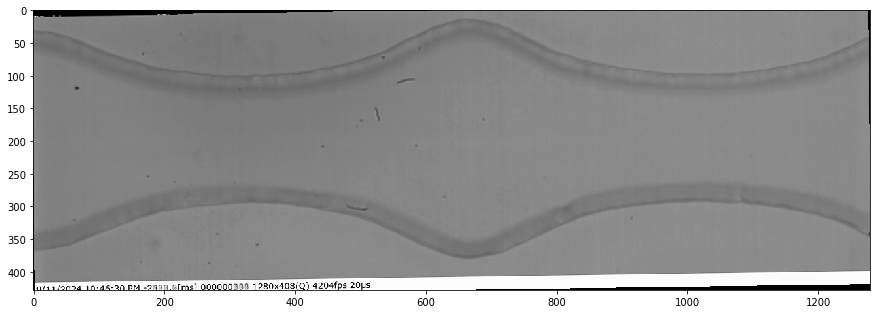

In [2]:
#################
froot = r'F:\Rheoflu\Tween80_Fig2'
img_name = 'tween80_2000h_acmc_20240911_104620_PM_20240911_104648_PM'
bkg_avgrange = [0,1000]
#################
fpath = os.path.join(froot, img_name + '.tif')
print('Image stack has shape: {0}, header: {1} bytes'.format(iof.get_stack_shape(fpath), iof.get_stack_headlen(fpath)))
t0 = time.time()
bkg = iof.compute_background(fpath, avg_range=bkg_avgrange)
print('Computing z average took {0:.2f} seconds'.format(time.time()-t0))
plt.figure(figsize=(15,7))
plt.imshow(bkg, cmap='Greys_r')

### 2: Analyze channel shape

Constriction parameters:
omega = 695.2 [rad/s]
sigma = 12.783 [Pa]
phi   = 0.141 [rad]
q     = 9.585 [mm2/s]
L0    = 136.9 [um]
wavelength = 467.0 [um]


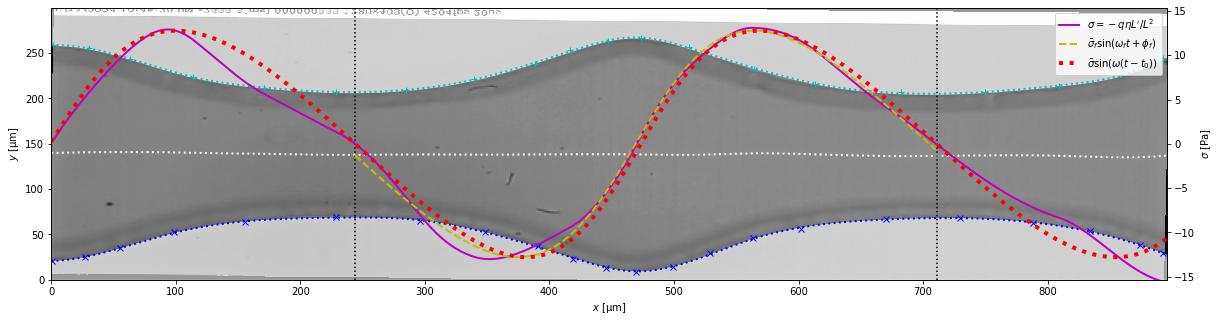

In [3]:
##########
px_size = 0.7 #um/px
fps = 4204    #1/s
eta = 0.058   #Pa.s
design_omega = 700
topedge_fpath = os.path.join(froot, img_name + '_edge1_px.txt')
bottomedge_fpath = os.path.join(froot, img_name + '_edge2_px.txt')
##########
params, shape, edges_um, chaxis_px, minpos_px = csa.AnalyzeChannelShape(bkg, bottomedge_fpath, topedge_fpath,
                                        px_size=px_size, design_omega=design_omega, eta=eta, save_fig=os.path.join(froot, img_name + '_chshape.png'))

In [4]:
print('constriction positions [px]: ' + str(minpos_px))
print('constriction positions [µm]: ' + str(['{0:.1f}'.format(pos*px_size) for pos in minpos_px]))
print('channel axis position [px]: ' + str(chaxis_px))

constriction positions [px]: [348, 1015]
constriction positions [µm]: ['243.6', '710.5']
channel axis position [px]: 197


(<Figure size 720x432 with 4 Axes>,
 array([<matplotlib.axes._subplots.AxesSubplot object at 0x00000213D6D75548>,
       dtype=object),
  <matplotlib.axes._subplots.AxesSubplot at 0x213d6c82d48>])

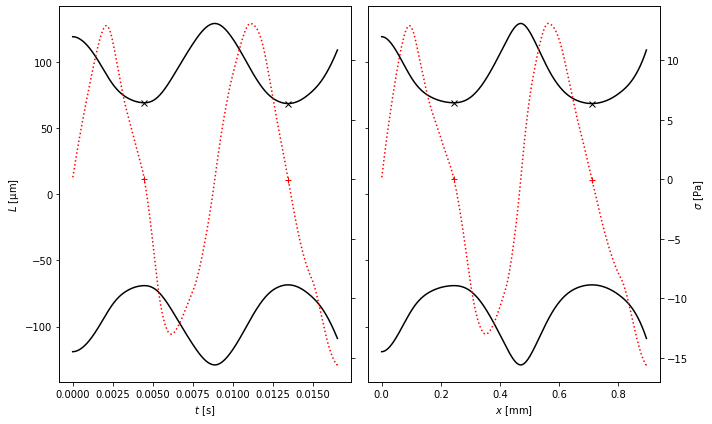

In [5]:
csa.plot_channel(*shape, q=params['q'], eta=eta)

### 3: Track droplets and compute stress

First, tune and test tracking parameters:

- ```[crop_margin_x, crop_margin_y]```: restrict search to a region around channel axis section between two constrictions 
- ```filter_range```: after locating and linking particles, disregard trajectories that are not fully contained in a narrower region
- ```filter_d```: search particles of a given diameter (in pixels, must be an odd integer)
- ```track_minmass, track_maxsize```: restrict locating features to masses and sizes smaller than given amounts
- ```search_range```: search range (in pixels) used by the linking algorithm
- ```track_zRange=[start_frame, end_frame]```: limit search to a substack. If ```None```, the entire stack is processed

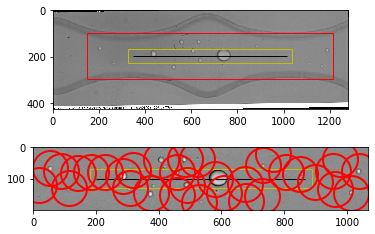

In [6]:
##########
filter_d = 35
crop_margin_x = 200
crop_size_y = 200
track_minmass = 800
track_maxsize = 80
track_nprocs = 4
search_range = [5, 40] # [search_y, search_x], in px/frame
filter_range = [20, 30] # [filter_x, filter_y], in px
bkgcorr_off = 150
track_zRange = None
roi_test_frame = 83
##########

out_root = os.path.join(froot, img_name + '_out_d' + str(filter_d))
iof.CheckCreateFolder(out_root)

if track_zRange is None:
    track_zRange = [0, iof.get_stack_shape(fpath)[0]]
if track_zRange[1] > iof.get_stack_shape(fpath)[0]:
    track_zRange[1] = iof.get_stack_shape(fpath)[0]

crop_ROI = da.get_track_roi(minpos_px, chaxis_px, crop_margin_x, crop_size_y, filter_range=filter_range, fpath=fpath, test_frame=roi_test_frame, 
            bkg=bkg, bkgcorr_off=bkgcorr_off, filter_d=filter_d, minmass=track_minmass, save_fig=os.path.join(out_root, img_name+'_FIG1_trackROI.png'))

Next, track particles across the entire stack

csv filename with track result already present: skip track calculation
480 particles have been tracked across the whole constriction


,Unnamed: 0,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
0,24,212.245894,165.046879,5912.072716,5.153278,0.050984,53.826712,133573.0,NaN,36,1
1,27,211.251136,195.436978,6078.081181,5.128460,0.034691,54.400529,134342.0,NaN,37,1
2,21,210.132839,227.922520,6022.789525,5.141665,0.022347,54.534881,134910.0,NaN,38,1
3,23,209.575125,262.159966,6110.333680,5.182568,0.025884,54.852323,134585.0,NaN,39,1
4,28,209.027707,297.863576,6129.856226,5.166998,0.007852,55.955373,134621.0,NaN,40,1


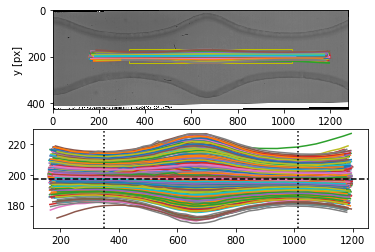

In [7]:
df_savepath = os.path.join(out_root, img_name+'_track.csv')
force_track = False
if os.path.isfile(df_savepath) and not force_track:
    print('csv filename with track result already present: skip track calculation')
    track_df = pd.read_csv(df_savepath)
    PID_list = track_df['particle'].unique()
else:
    track_filter = [[minpos_px[0]-filter_range[0], minpos_px[1]+filter_range[0]],
                    [chaxis_px-filter_range[1], chaxis_px+filter_range[1]]]
    fstack = iof.get_stack(fpath, track_zRange, cropROI=crop_ROI, bkg=bkg, bkgcorr_offset=bkgcorr_off)
    track_df, PID_list = da.track_droplets(fstack, stack_offset=[track_zRange[0], crop_ROI[1], crop_ROI[0]], diameter=filter_d, minmass=track_minmass, 
                      maxsize=track_maxsize, filter_range=track_filter, search_range=search_range, link_memory=0, 
                        track_out_fpath=os.path.join(out_root, img_name+'.h5'), track_procs=track_nprocs, df_savepath=df_savepath)
da.plot_trajectories(track_df, bkg_img=bkg, PID_list=PID_list, chaxis_px=chaxis_px, constr_pos=minpos_px, filter_range=filter_range,
                    save_fig=os.path.join(out_root, img_name+'_FIG2_trajectories.png'))
track_df.head()

Now process particle trajectories, extract particle speed, $v_d(x)$, and compute stress on the particle: $\sigma_{ext}^d=\eta \partial v_d/\partial x$. First let's do that on one single track:

  +----------------------------------------------+
  |       TRACE ANALYSIS FOR DROPLET 00001:      |
  +----------------------------------------------+
  | Maximum droplet speed:  vmax =  107.73 mm/s  |
  | Frequency:             omega =  1015.9 rad/s |
  | Planar flow rate (est.):   q =   14.75 mm2/s |
  | Reduced frequency (exp)  w/q =   68.86 1/mm2 |
  | Reduced frequency (params)   =   72.53 1/mm2 |
  | Real stress amplitude: sigma =    18.7 Pa    |
  | Stress amplitude (params): s =    12.8 Pa    |
  +----------------------------------------------+


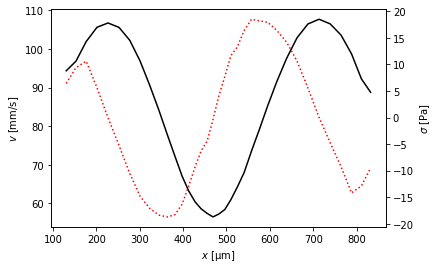

In [8]:
x_pos, v, stress = da.calc_droplet_stress(track_df[(track_df['particle'] == PID_list[3])]['x'], 
                                          px_size=px_size, fps=fps, eta=eta, params=params, verbose=2, pID=PID_list[0], plot=True)

Then on all tracks: filter spurious trajectories by setting a threshold on $max(\sigma^2)/\langle\sigma^2\rangle$, which should be equal to 2 for harmonic oscillations

64/480 droplets excluded from the analysis
Max displacement between adjacent frames: [37.4, 2.6] pixels


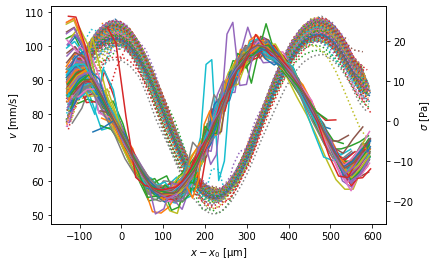

In [9]:
##########
filter_ss_maxtomean = 4
##########
PID_sel = da.track_postproc(track_df, px_size=px_size, fps=fps, eta=eta, ss_maxtomean=filter_ss_maxtomean, plot=True, verbose=0, x_off=minpos_px[0]*px_size, 
                           save_fig=os.path.join(out_root, img_name+'_FIG3_speedstress.png'))

### 4: Measure droplet deformation

First, find droplet edges with subpixel resolution, and filter resulting datapoints to only get the outer edge of the droplet

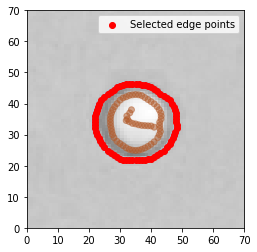

In [10]:
##########
edge_roi_size = 35
edge_blur = 2
edge_dbscan_eps = 2.1
edge_thr = 4.5
edge_iterN = 4
filter_r_thr = 100
##########

_, drop_img = da.drop_cropROI(track_df, pID=PID_sel[0], frame=20, roi_size=edge_roi_size, rel_frame=True, 
                              fpath=fpath, bkg=bkg, bkgcorr_offset=bkgcorr_off, blur_sigma=edge_blur)
drop_edges = da.find_edges(drop_img, edge_threshold=edge_thr, smoothing_iterN=edge_iterN, dbscan_eps=edge_dbscan_eps, dbscan_minN=1, plot=True)

Then, fit the outer edge with a Fourier series truncated to the $n$-th order, with $n=5$


----------+------+-------+-------+-------+-------
Parameter | unit |  raw  | guess | value | err
----------+------+-------+-------+-------+-------
    x0    |  px  |  0.00 |  0.00 |  0.00 | 0.002
    y0    |  px  |  0.00 | -0.00 |  0.00 | 0.002
   rbar   |  px  | 12.80 | 12.80 | 12.80 | 0.018
  gamma_2 |  %   |  3.57 |  3.33 |  3.34 | 0.196
  gamma_3 |  %   |  0.00 |  0.00 |  0.79 | 0.203
  gamma_4 |  %   |  0.00 |  0.00 |  0.03 | 0.206
  gamma_5 |  %   |  0.00 |  0.00 | -0.36 | 0.204
----------+------+-------+-------+-------+-------

Fine-tuned center: (0.003,0.000). Guess from circle fit: (-0.000,-0.000)
Droplet radius: guess=12.80 px, circle fit=12.80 px, Final fit=12.80 px
Elliptical deformation: guess=3.57%, elliptical fit=3.33%, Final fit=3.34%
Higher-order deformation coefficients: g3=0.79%, g4=0.03%, g4=-0.36%
Non-elliptical deformation parameter: 0.353
RMS fit error: 0.022 px (elliptical RMS error: 0.028 px), fit R2: 0.826


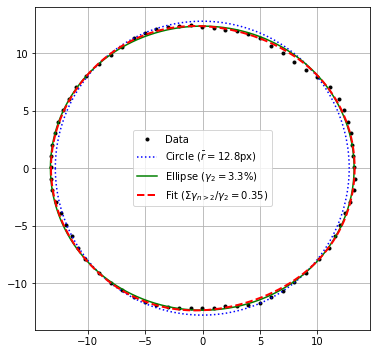

In [11]:
fit_res = da.fit_edge(drop_edges, filter_r_thr=filter_r_thr, print_res=True, plot=True, plot_savedir=out_root)

Now do that for all frames and all particles

In [12]:
##########
save_all_edgefigs = False
##########

defdf_savepath = os.path.join(out_root, img_name+'_def.csv')
force_def = False
if os.path.isfile(defdf_savepath) and not force_def:
    print('csv filename with deformation result already present: skip deformation calculation')
    track_df = pd.read_csv(defdf_savepath)
    PID_sel = track_df['particle'].unique()
else:
    if save_all_edgefigs:
        edges_plot_outdir = os.path.join(froot, 'out_tmp')
    else:
        edges_plot_outdir = None
    def_res, PID_sel = da.analyze_deformations(fpath, track_df, crop_roi_size=edge_roi_size, img_bkg=bkg, img_bkgcorr_offset=bkgcorr_off, 
                                               img_blur_sigma=edge_blur, edge_threshold=edge_thr, smoothing_iterN=edge_iterN, 
                                               dbscan_eps=edge_dbscan_eps, dbscan_minN=1, filter_r_thr=filter_r_thr, 
                                               plot_outdir=edges_plot_outdir, px_size=px_size, fps=fps, PID_list=PID_sel)
    track_df.to_csv(defdf_savepath)
track_df

csv filename with deformation result already present: skip deformation calculation


,Unnamed: 0,y,x,mass,size,ecc,signal,raw_mass,ep,frame,...,fit_g5_er,fit_R2,fit_mserr,fit_rmean,fit_rawg2,fit_r0_el,fit_x0_el,fit_y0_el,fit_g2_el,fit_nonel
0,24,212.245894,165.046879,5912.072716,5.153278,0.050984,53.826712,133573.0,NaN,36,...,0.002208,0.991770,0.021687,12.877168,0.036671,13.065435,-0.161722,-0.090466,0.042686,0.439147
1,27,211.251136,195.436978,6078.081181,5.128460,0.034691,54.400529,134342.0,NaN,37,...,0.001501,0.993127,0.011315,12.994154,0.057468,13.094879,-0.120499,-0.055046,0.058916,0.125495
2,21,210.132839,227.922520,6022.789525,5.141665,0.022347,54.534881,134910.0,NaN,38,...,0.003327,0.988967,0.037709,12.638803,0.034516,12.886746,-0.214658,-0.049035,0.049302,0.238381
3,23,209.575125,262.159966,6110.333680,5.182568,0.025884,54.852323,134585.0,NaN,39,...,0.002341,0.990884,0.022772,12.871718,0.034487,13.051063,-0.175223,-0.051913,0.040154,0.352333
4,28,209.027707,297.863576,6129.856226,5.166998,0.007852,55.955373,134621.0,NaN,40,...,0.004387,0.983126,0.049729,12.562112,0.006556,12.784307,-0.206810,-0.004929,0.031899,0.616020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17677,21,195.043448,1040.022394,9974.890372,6.772767,0.010151,45.140510,134015.0,NaN,12537,...,0.001304,0.761664,0.020883,16.798001,0.020713,16.798414,-0.005420,0.004477,0.019705,0.252906
17678,20,194.782050,1075.826745,9753.692153,6.769562,0.011436,43.340199,134222.0,NaN,12538,...,0.001058,0.599584,0.013515,16.742855,0.007125,16.743607,-0.007957,0.005149,0.005396,1.242607
17679,23,194.705388,1110.492246,9989.911131,6.805867,0.046719,44.542872,134655.0,NaN,12539,...,0.001268,0.754609,0.019892,16.721322,-0.021243,16.721771,-0.002419,-0.006907,-0.018760,0.314751
17680,22,194.354413,1143.439328,9848.598724,6.878915,0.068856,43.724028,133921.0,NaN,12540,...,0.000971,0.922970,0.011502,16.705170,-0.029128,16.705181,-0.000956,-0.000737,-0.030040,0.197668


$\bar r$ should be constant, independent on $x$: we use this to discriminate droplets for which the fit procedure doesn't work very well, and only consider particles for which the shape reconstruction is robust across all droplet positions

235 excluded particles, final analysis will be fine tuned on 245 particles:
[1, 4, 7, 8, 27, 32, 34, 44, 63, 128, 132, 138, 139, 143, 154, 160, 166, 170, 171, 175, 189, 197, 201, 205, 207, 208, 230, 234, 238, 257, 258, 260, 265, 280, 283, 284, 287, 288, 289, 293, 333, 339, 362, 512, 531, 564, 698, 753, 756, 758, 762, 765, 769, 770, 797, 799, 806, 834, 854, 885, 893, 895, 898, 914, 915, 926, 929, 930, 936, 937, 939, 947, 948, 966, 987, 1006, 1010, 1013, 1015, 1152, 1153, 1162, 1163, 1164, 1168, 1174, 1177, 1187, 1189, 1190, 1191, 1199, 1201, 1202, 1204, 1208, 1210, 1219, 1221, 1225, 1237, 1241, 1246, 1247, 1249, 1263, 1264, 1274, 1276, 1282, 1285, 1287, 1288, 1289, 1291, 1301, 1311, 1317, 1322, 1337, 1346, 1349, 1351, 1360, 1375, 1377, 1378, 1379, 1401, 1430, 1478, 1488, 1489, 1491, 1494, 1522, 1526, 1529, 1530, 1531, 1533, 1534, 1674, 1685, 1727, 1741, 1742, 1743, 1812, 1813, 1822, 1845, 1894, 1898, 1904, 1905, 1908, 1910, 1911, 1924, 1925, 1926, 1928, 1934, 1935, 1940, 2020, 2021, 204

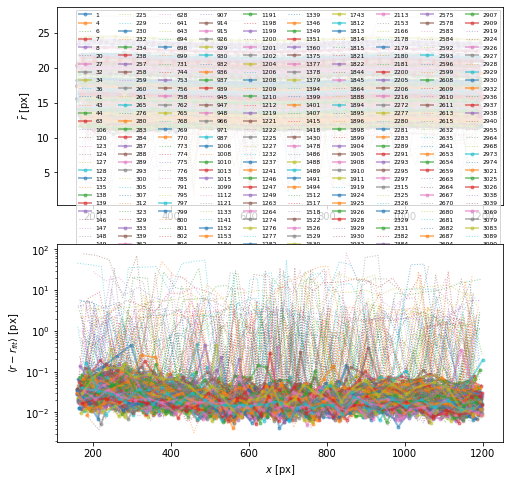

In [13]:
##########
filter_rbar_relstd = 0.02
filter_rtheta_mserr = 0.5
##########

filter_img_fpath = os.path.join(out_root, img_name+'_FIG4_filter_droplets.png')
PID_sel = da.filter_droplets(track_df, thr_relstd=filter_rbar_relstd, thr_mserr=filter_rtheta_mserr, 
                             PID_list=PID_sel, save_fig=filter_img_fpath)

### 5: Droplet rheology

Plot Lissajous curves

64/480 droplets excluded from the analysis
Max displacement between adjacent frames: [37.4, 2.6] pixels


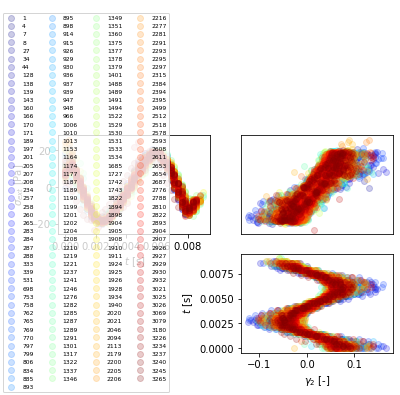

In [14]:
PID_sel = da.plot_lissajous(track_df, pID_subset=PID_sel, recalc_stress=True, px_size=px_size, 
                            fps=fps, eta=eta, ss_maxtomean=filter_ss_maxtomean, plot_alpha=0.2,
                            save_txt=os.path.join(out_root, img_name+'_stressstrain_avg.txt'), save_txt_format='avg')

To compute viscoelastic moduli for one given droplet, we need to fit both stress and strain with a common frequency

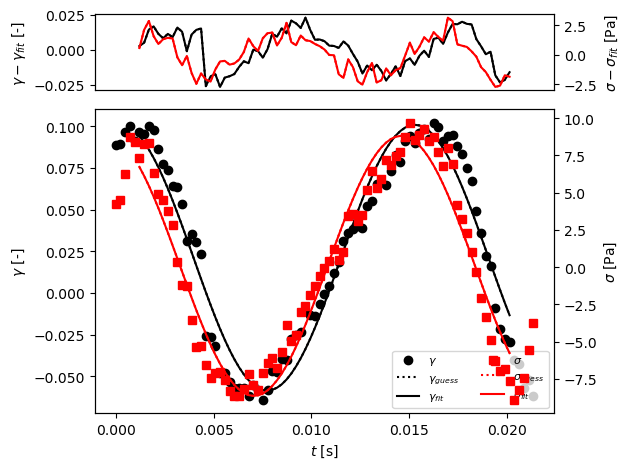

In [17]:
########
ss_fit_margin = 5
ss_param_bound = 0
ss_globalfit_iter = 4
########

pID = PID_sel[0]
fit_res = da.calculate_modulus(gamma=track_df[(track_df['particle'] == pID)]['fit_g2'],
                            sigma=track_df[(track_df['particle'] == pID)]['stress'], 
                               fps=fps, fit_margin=ss_fit_margin, param_bound=ss_param_bound, pre_fit_iter=ss_globalfit_iter, plot=True)

Do that for all selected droplets

droplet radius : 15.0 +/- 1.7 px
frequency      : 416.2 +/- 5.2 rad/s
storage modulus: 117.5 +/- 15.6 Pa
loss modulus   : 34.6 +/- 12.1 Pa


,G*,delta,Gp,Gs,strain_off,stress_off,strain_amp,stress_amp,strain_ph,stress_ph,omega,npts,rbar,v_avg,yavg,particle
0,109.567933,0.287430,105.072983,31.061235,0.021150,0.080677,0.079628,8.724643,1.483588,1.771018,417.024742,79,14.083133,0.035043,214.676397,17
1,144.456781,0.203766,141.468186,29.232066,0.013125,0.079166,0.059456,8.588882,1.593396,1.797162,413.037759,80,15.762299,0.034667,176.502047,113
2,105.286668,0.308475,100.316904,31.965626,0.021012,0.088067,0.083278,8.768038,1.457632,1.766107,420.530429,78,13.920060,0.035310,180.446175,260
3,108.655844,0.266466,104.821121,28.611623,0.017228,0.092512,0.079877,8.679089,1.499742,1.766207,416.575229,79,15.041481,0.034948,179.136303,334
4,111.828768,0.292444,107.080748,32.239521,0.025511,0.075577,0.078573,8.786735,1.496858,1.789303,418.727301,79,13.028572,0.035123,173.258477,335


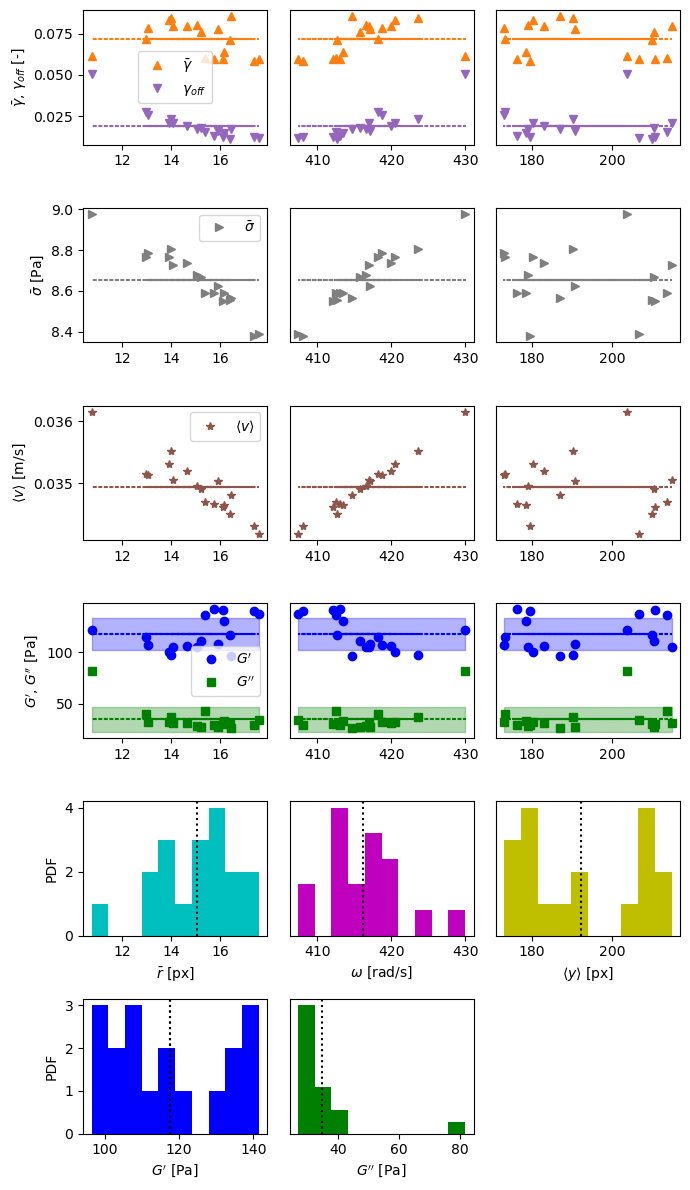

In [18]:
moduli_csv_fpath = os.path.join(out_root, img_name+'_moduli.csv')
moduli_img_fpath = os.path.join(out_root, img_name+'_FIG6_moduli.png')
moduli_df = da.calc_moduli(track_df, PID_list=PID_sel, fps=fps, fit_margin=ss_fit_margin, param_bound=ss_param_bound, 
                           pre_fit_iter=ss_globalfit_iter, plot=True, save_csv=moduli_csv_fpath, save_fig=moduli_img_fpath)
moduli_df.head()

Plot Lissajous curves sorted by $G^\prime$

43/123 droplets excluded from the analysis
Max displacement between adjacent frames: [17.0, 0.9] pixels


D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:524: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  stress_fit = float(mod_curp['stress_off']) + float(mod_curp['stress_amp'])*np.sin(float(mod_curp['omega'])*t + float(mod_curp['stress_ph']))
D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:525: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  strain_fit = float(mod_curp['strain_off']) + float(mod_curp['strain_amp'])*np.sin(float(mod_curp['omega'])*t + float(mod_curp['strain_ph']))


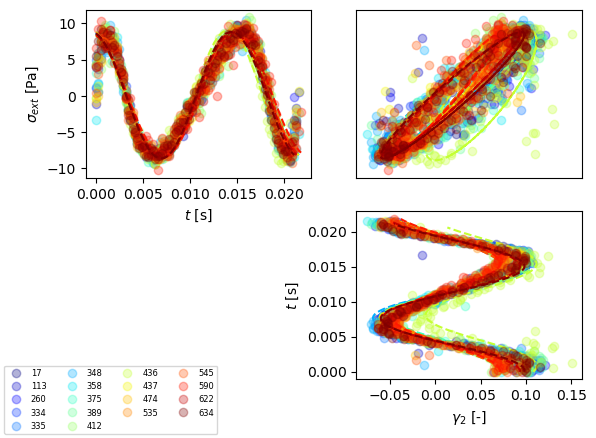

In [19]:
LB_img_fpath = os.path.join(out_root, img_name+'_FIG5_LB.png')
PID_sel_sorted = da.plot_lissajous(track_df, pID_subset=PID_sel, mod_df=moduli_df, recalc_stress=True, px_size=px_size, 
                            fps=fps, eta=eta, ss_maxtomean=filter_ss_maxtomean, plot_alpha=0.3, save_fig=LB_img_fpath)

Save all analysis params to ASCII file

In [20]:
params = {'froot' : froot,
          'img_name' : img_name,
          'bkg_avgrange' : bkg_avgrange,
          'topedge_fpath' : topedge_fpath,
          'bottomedge_fpath' : bottomedge_fpath,
          'px_size' : px_size,
          'fps' : fps,
          'eta' : eta,
          'design_omega' : design_omega,
          'filter_d' : filter_d,
          'crop_margin_x' : crop_margin_x,
          'crop_size_y' : crop_size_y,
          'track_minmass' : track_minmass,
          'track_maxsize' : track_maxsize,
          'track_nprocs' : track_nprocs,
          'search_range' : search_range,
          'filter_range' : filter_range,
          'bkgcorr_off' : bkgcorr_off,
          'track_zRange' : track_zRange,
          'roi_test_frame' : roi_test_frame,
          'filter_ss_maxtomean' : filter_ss_maxtomean,
          'edge_roi_size' : edge_roi_size,
          'edge_blur' : edge_blur,
          'edge_dbscan_eps' : edge_dbscan_eps,
          'edge_thr' : edge_thr,
          'edge_iterN' : edge_iterN,
          'save_all_edgefigs' : save_all_edgefigs,
          'filter_r_thr' : filter_r_thr,
          'filter_rbar_relstd' : filter_rbar_relstd,
          'filter_rtheta_mserr' : filter_rtheta_mserr,
          'ss_fit_margin' : ss_fit_margin,
          'ss_param_bound' : ss_param_bound,
          'ss_globalfit_iter' : ss_globalfit_iter,
          }


params_fpath = os.path.join(out_root, img_name+'_analysisParams.log')
with open(params_fpath, 'w') as fout:
    json.dump(params, fout, indent=2)

Using this, one can run the full analysis with the same set of parameters:

Analysis parameters loaded from configuration file: D:\steaime\Data\Rheoflu\Wenyun_Tween80_0p56\out_d25\tween80_0p56_1000ulh_w4_20251103_20110_PM_20251103_020209_PM_analysisParams.log

### 1: LOAD IMAGE SEQUENCE
Working in root folder D:\steaime\Data\Rheoflu\Wenyun_Tween80_0p56
Loading image tween80_0p56_1000ulh_w4_20251103_20110_PM_20251103_020209_PM.tif
Image stack has shape: (13905, 436, 1280)
Computing z average took 4.94 seconds

### 2: ANALYZE CHANNEL SHAPE
Constriction parameters:
omega = 654.2 [rad/s]
sigma = 13.459 [Pa]
phi   = 1.115 [rad]
q     = 8.925 [mm2/s]
L0    = 116.5 [um]
wavelength = 485.0 [um]
constriction positions [px]: [290, 982]
constriction positions [µm]: [203.0, 687.4]
channel axis position [px]: 190

### 3: TRACK DROPLETS AND COMPUTE STRESSES
csv filename with track result already present: skip track calculation
203 particles have been tracked across the whole constriction
54/203 droplets excluded from the analysis
Max displacement between adjacent frames: [2

D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:524: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  stress_fit = float(mod_curp['stress_off']) + float(mod_curp['stress_amp'])*np.sin(float(mod_curp['omega'])*t + float(mod_curp['stress_ph']))
D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:525: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  strain_fit = float(mod_curp['strain_off']) + float(mod_curp['strain_amp'])*np.sin(float(mod_curp['omega'])*t + float(mod_curp['strain_ph']))



Analysis completed in 12.44 seconds. Parameters saved to file D:\steaime\Data\Rheoflu\Wenyun_Tween80_0p56\out_d25\tween80_0p56_1000ulh_w4_20251103_20110_PM_20251103_020209_PM_analysisParams.log


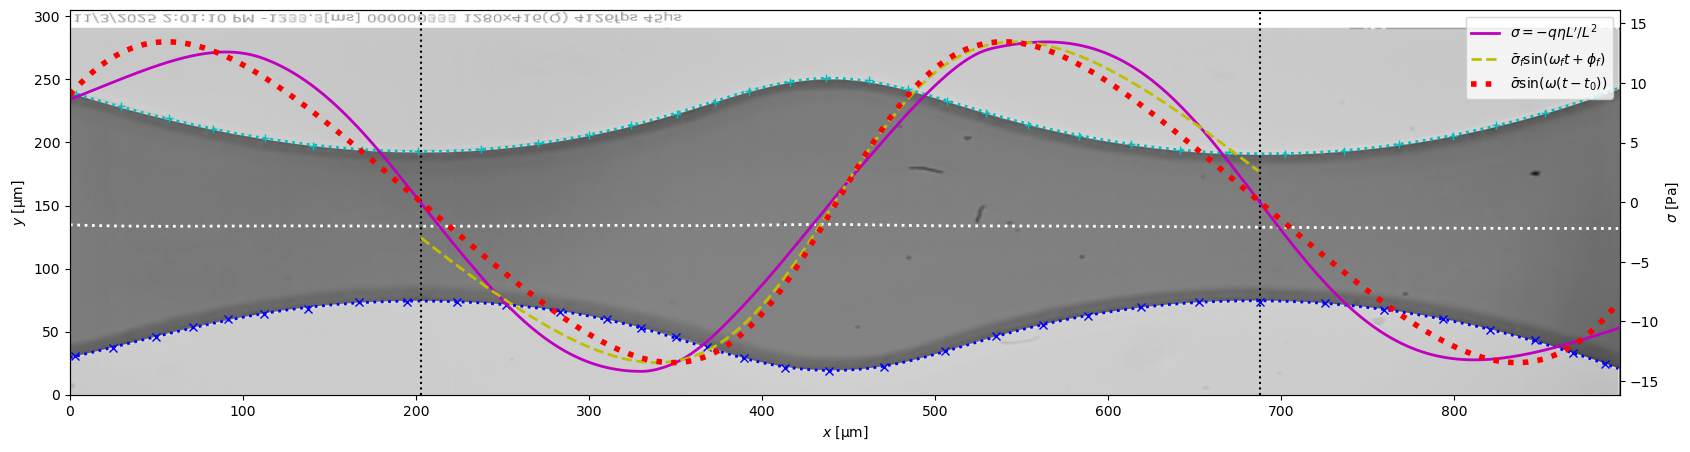

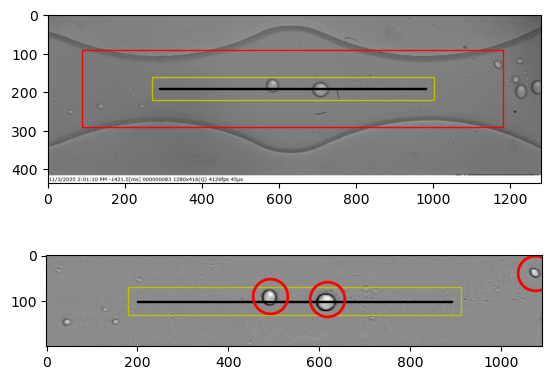

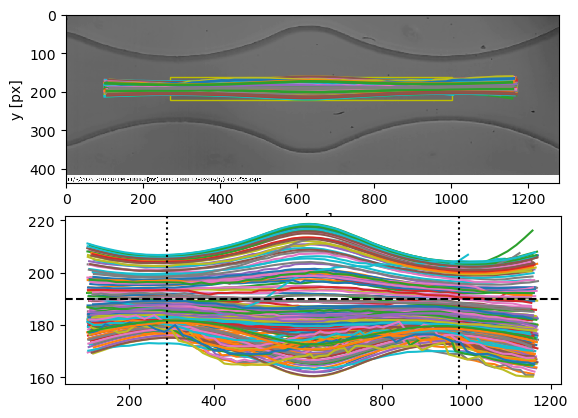

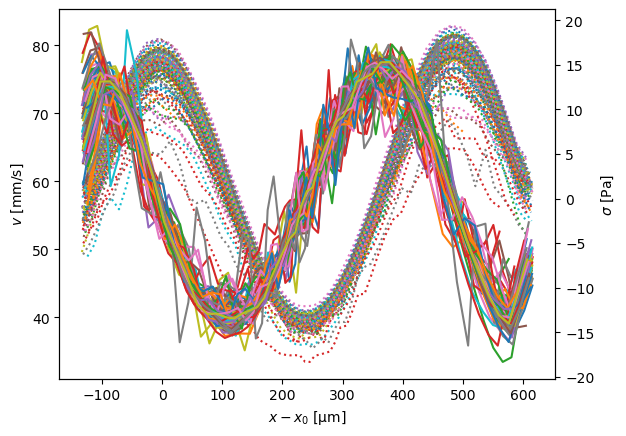

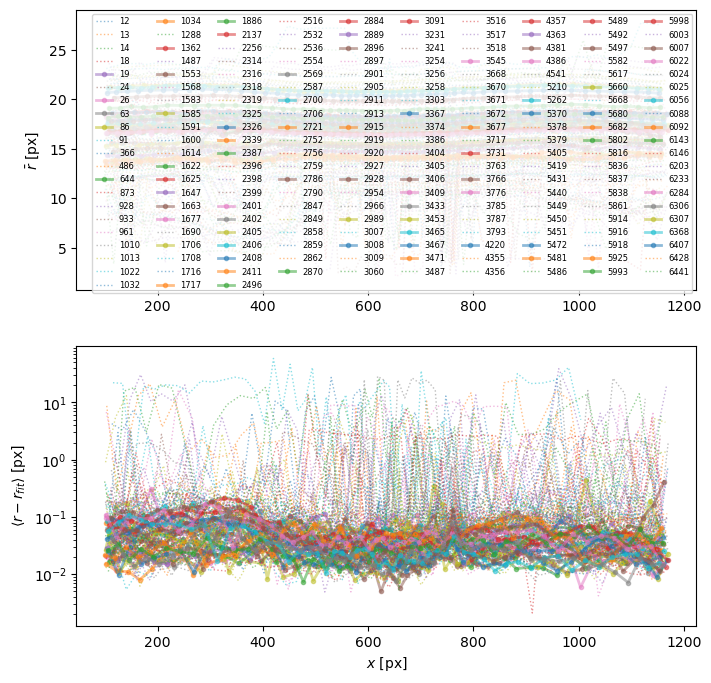

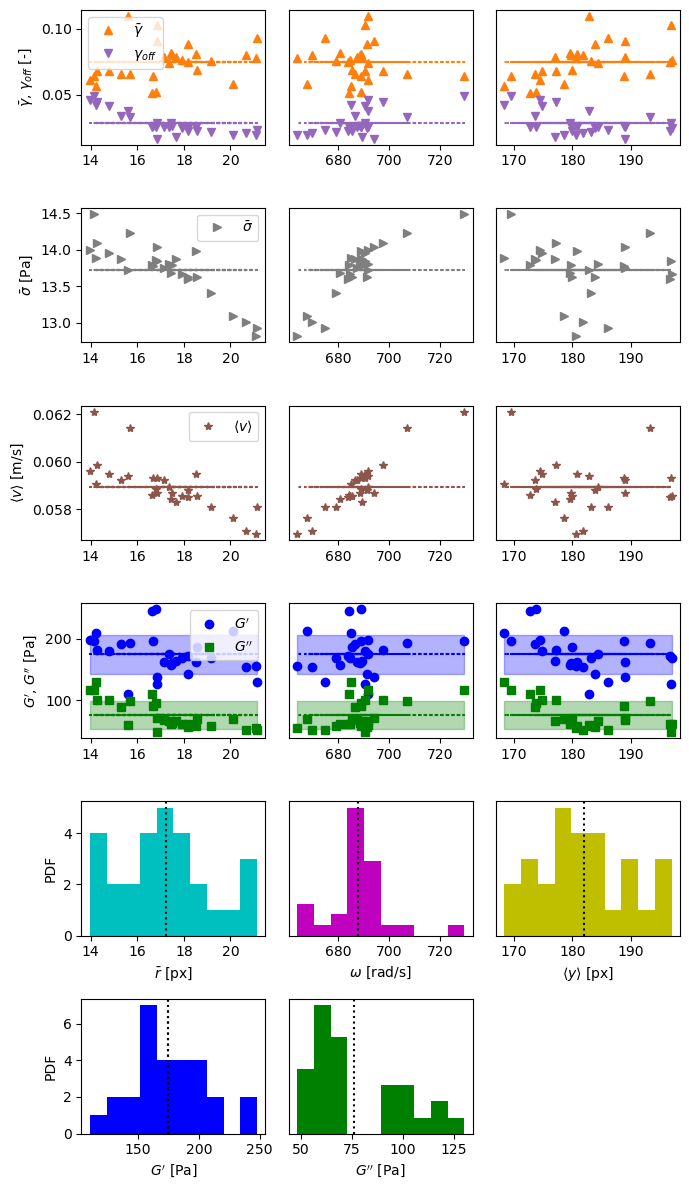

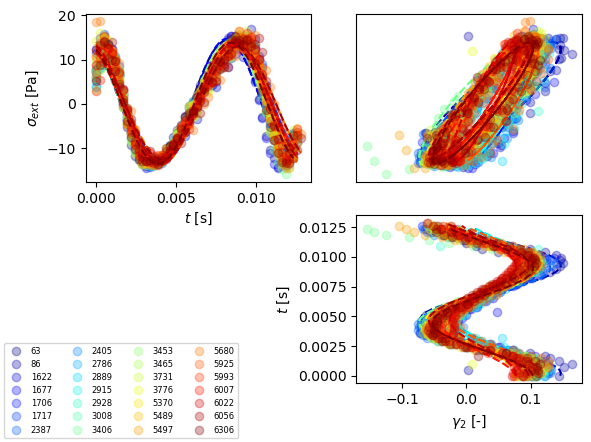

In [19]:
Rheoflu.rheoflu_analysis(params_fpath)

Alternatively, analysis parameters can be overridden by kwargs:

Analysis parameters loaded from configuration file: D:\steaime\Data\Rheoflu\Wenyun_Tween80_0p56\out_d25\tween80_0p56_1000ulh_w4_20251103_20110_PM_20251103_020209_PM_analysisParams.log
param[filter_d] updated from 25 to 35 using function kwargs
param[track_minmass] updated from 2000 to 4000 using function kwargs

### 1: LOAD IMAGE SEQUENCE
Working in root folder D:\steaime\Data\Rheoflu\Wenyun_Tween80_0p56
Loading image tween80_0p56_1000ulh_w4_20251103_20110_PM_20251103_020209_PM.tif
Image stack has shape: (13905, 436, 1280)
Computing z average took 5.38 seconds

### 2: ANALYZE CHANNEL SHAPE
Constriction parameters:
omega = 654.2 [rad/s]
sigma = 13.459 [Pa]
phi   = 1.115 [rad]
q     = 8.925 [mm2/s]
L0    = 116.5 [um]
wavelength = 485.0 [um]
constriction positions [px]: [290, 982]
constriction positions [µm]: [203.0, 687.4]
channel axis position [px]: 190

### 3: TRACK DROPLETS AND COMPUTE STRESSES
csv filename with track result already present: skip track calculation
154 particles have b

D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:316: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(r_theta_higherorder, theta, r, method=method, p0=guessp, bounds=pbounds)


Now processing particle 5/126 (PID: 28)...
Now processing particle 6/126 (PID: 36)...
Now processing particle 7/126 (PID: 514)...
Now processing particle 8/126 (PID: 582)...
Now processing particle 9/126 (PID: 611)...
Analysis failed on frame 996: too few edge datapoints to fit. Skipping entire particle 611.
Now processing particle 10/126 (PID: 614)...
Now processing particle 11/126 (PID: 627)...


D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:316: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(r_theta_higherorder, theta, r, method=method, p0=guessp, bounds=pbounds)


Now processing particle 12/126 (PID: 650)...
Now processing particle 13/126 (PID: 652)...
Now processing particle 14/126 (PID: 653)...
Now processing particle 15/126 (PID: 909)...
Now processing particle 16/126 (PID: 1000)...
Now processing particle 17/126 (PID: 1006)...
Now processing particle 18/126 (PID: 1010)...
Now processing particle 19/126 (PID: 1015)...
Now processing particle 20/126 (PID: 1021)...
Now processing particle 21/126 (PID: 1025)...
Now processing particle 22/126 (PID: 1048)...
Now processing particle 23/126 (PID: 1051)...
Now processing particle 24/126 (PID: 1054)...
Now processing particle 25/126 (PID: 1055)...
Now processing particle 26/126 (PID: 1059)...
Now processing particle 27/126 (PID: 1440)...
Now processing particle 28/126 (PID: 1463)...
Now processing particle 29/126 (PID: 1464)...
Now processing particle 30/126 (PID: 1465)...
Now processing particle 31/126 (PID: 1466)...
Now processing particle 32/126 (PID: 1467)...
Now processing particle 33/126 (PID: 1

...

Now processing particle 91/126 (PID: 2682)...
Now processing particle 92/126 (PID: 3163)...
Now processing particle 93/126 (PID: 3193)...


D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:316: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(r_theta_higherorder, theta, r, method=method, p0=guessp, bounds=pbounds)


Now processing particle 94/126 (PID: 3259)...
Now processing particle 95/126 (PID: 3262)...
Now processing particle 96/126 (PID: 3263)...
Now processing particle 97/126 (PID: 3282)...
Now processing particle 98/126 (PID: 3290)...
Now processing particle 99/126 (PID: 3301)...
Now processing particle 100/126 (PID: 3304)...
Now processing particle 101/126 (PID: 3328)...
Now processing particle 102/126 (PID: 3330)...
Now processing particle 103/126 (PID: 3332)...
Now processing particle 104/126 (PID: 3334)...
Now processing particle 105/126 (PID: 3383)...
Now processing particle 106/126 (PID: 3402)...
Now processing particle 107/126 (PID: 3421)...
Now processing particle 108/126 (PID: 3423)...
Now processing particle 109/126 (PID: 3486)...
Now processing particle 110/126 (PID: 3496)...
Now processing particle 111/126 (PID: 3510)...
Analysis failed on frame 11358: too few edge datapoints to fit. Skipping entire particle 3510.
Now processing particle 112/126 (PID: 3543)...
Now processing par

D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:524: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  stress_fit = float(mod_curp['stress_off']) + float(mod_curp['stress_amp'])*np.sin(float(mod_curp['omega'])*t + float(mod_curp['stress_ph']))
D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\Rheoflu\DropletAnalysis.py:525: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  strain_fit = float(mod_curp['strain_off']) + float(mod_curp['strain_amp'])*np.sin(float(mod_curp['omega'])*t + float(mod_curp['strain_ph']))



Analysis completed in 2557.51 seconds. Parameters saved to file D:\steaime\Data\Rheoflu\Wenyun_Tween80_0p56\out_d35\tween80_0p56_1000ulh_w4_20251103_20110_PM_20251103_020209_PM_analysisParams.log


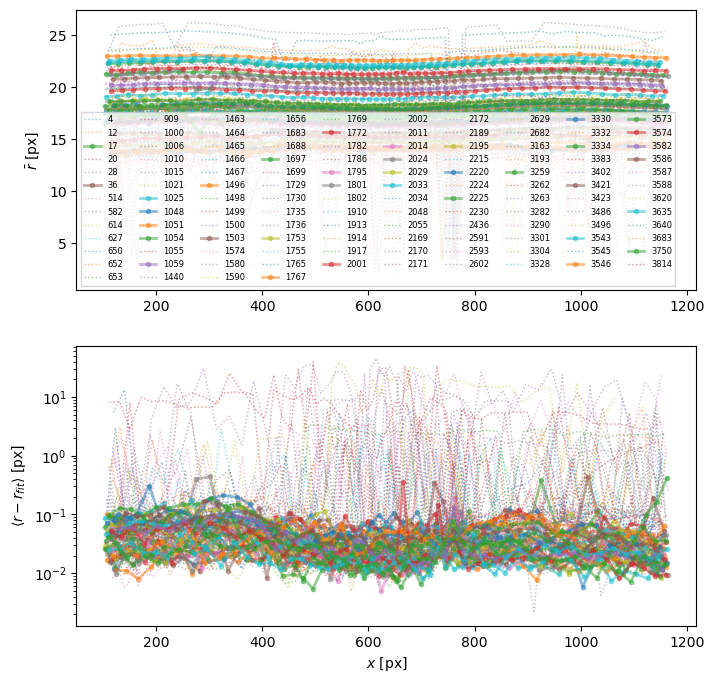

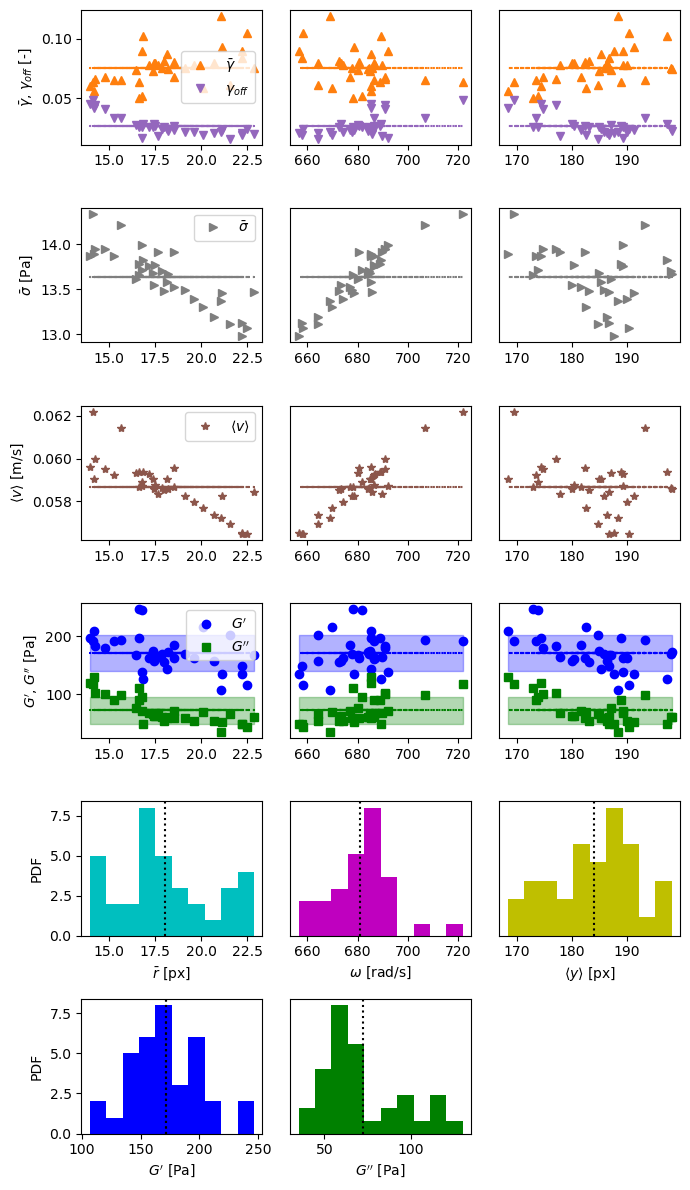

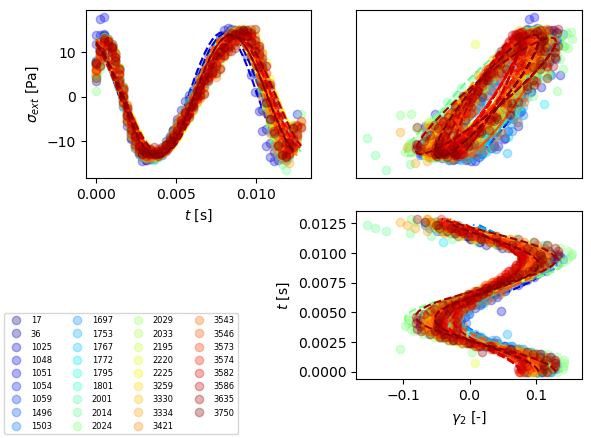

In [20]:
Rheoflu.rheoflu_analysis(params_fpath, filter_d=35, track_minmass=4000)